# Cluster Membership Tracking (first few simple metrics)

In this notebook we compute some simple metrics on the cluster membership stability. Previously we have fixed the number of clusters and have applied a matching algorithm so that we have labels for clusters in consecutive weeks that are comparable (i.e point x stayed in the same 'cluster').

In [1]:
# Main packages 
import polars as pl
import matplotlib.pyplot as plt
import numpy as np

# Clustering packages
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score, calinski_harabasz_score, davies_bouldin_score,adjusted_rand_score

# Optimisation packages
from scipy.optimize import linear_sum_assignment

# Parallel processing packages
from joblib import Parallel, delayed

In [2]:
# Load data
df = pl.scan_csv("/home/lanl/data/cyber1/auth.txt.gz",has_header=False,separator=",",
                 new_columns= ['time','src_user','dest_user','src_comp','dest_comp',
                               'auth_type','logon_type','auth_orientation','outcome'])

In [3]:
# Keep only human users
df = df.filter(pl.col("src_user").str.starts_with("U"))

## Functions & Global info

In [4]:
# Time conversions
seconds_in_day = 60 * 60 * 24

# Time aggregation
agg_hour_level = 1

# Number of buckets in a week of data
buckets_per_week = (7 * 24) // agg_hour_level

# Silhouette sample size 
sample_size = 1000

In [5]:
# FUNCTION - build features dataframe
def build_features(df,agg_hour_level):

    agg_seconds = agg_hour_level * 60 * 60

    return (
        df.with_columns(
            bucket = pl.col('time') // agg_seconds,
            theta = ((pl.col('time') % seconds_in_day)/ seconds_in_day) * 2 * np.pi,
            is_failure = (pl.col('outcome') == 'Fail').cast(pl.Int8),
        )
        .group_by(['src_user','bucket'])
        .agg(
            n_events = pl.len(),
            failure_ratio = pl.col('is_failure').mean(),
            n_distinct_dest = pl.col('dest_comp').n_unique(),
            n_distinct_src = pl.col('src_comp').n_unique(),
            c_bar = pl.col('theta').cos().mean(),
            s_bar = pl.col('theta').sin().mean(),
        )
        .with_columns(
             log_n_events=pl.col("n_events").log1p(),
             log_n_distinct_dest=pl.col("n_distinct_dest").log1p(),
             log_n_distinct_src=pl.col("n_distinct_src").log1p(),
        )
        .collect()
    )

In [6]:
# Relevant feauture columns
feature_cols = [
    "log_n_events",
    "failure_ratio",
    "log_n_distinct_dest",
    "log_n_distinct_src",
    "c_bar",
    "s_bar",
]

In [7]:
# FUNCTION - process features for clustering 
def cluster_preprocess(features_df,feature_cols,week):

    lb = (week - 1) * buckets_per_week
    ub = lb + buckets_per_week - 1

    features_week = features_df.filter(pl.col('bucket').is_between(lb,ub))

    X = features_week.select(feature_cols).to_numpy()
    scaler = StandardScaler()
    X_scaled = scaler.fit_transform(X)

    return features_week, X_scaled

In [8]:
# FUNCTION - kmeans 
def fit_kmeans(k, Y, sample_size):
    km = KMeans(n_clusters=k, random_state=123, n_init=10)
    labels = km.fit_predict(Y)
    
    sil = silhouette_score(Y, labels, sample_size=sample_size, random_state=123)
    ch  = calinski_harabasz_score(Y, labels)   
    db  = davies_bouldin_score(Y, labels)    
    
    return k, sil,ch,db

In [9]:
# Create features dataframe
features_df = build_features(df,agg_hour_level)

## Clustering

In [10]:
# Cluster for each week
n_weeks = 8
k = 3
weekly_results = {}

for week in range(1, n_weeks + 1):

    features_week, X_scaled = cluster_preprocess(features_df, feature_cols, week=week)

    km = KMeans(n_clusters=k, random_state=123, n_init=10) 
    labels = km.fit_predict(X_scaled)   

    features_week = (features_week.with_columns(pl.Series("cluster", labels)).select(['src_user','bucket','cluster']))

    weekly_results[week] = features_week

## Membership Tracking

In [13]:
JACARD = np.zeros((n_weeks - 1,k,k))
aligned_labels = {}

for week in range(1,n_weeks):
    
    w_curr = weekly_results[week].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    w_next = weekly_results[week + 1].with_columns(
        relative_bucket=pl.col('bucket') % buckets_per_week
    )

    overlap = w_curr.join(w_next, on=['src_user', 'relative_bucket'], how='inner', suffix='_next')

    labels_curr = overlap['cluster'].to_numpy()
    labels_next = overlap['cluster_next'].to_numpy()

    for i in range(k):
        mask_i = (labels_curr == i)
        
        for j in range(k):
            mask_j = labels_next == j
            intersection = np.sum(mask_i & mask_j)
            union = np.sum(mask_i | mask_j)
            JACARD[week - 1, i,j] = intersection/union 

    _, col_ind = linear_sum_assignment(JACARD[week - 1], maximize=True)

    mapping = {col_ind[c]: c for c in range(k)}
    labels_next = np.array([mapping[label] for label in labels_next])

    aligned_labels[week] = {
        'src_user': overlap['src_user'].to_numpy(),
        'relative_bucket': overlap['relative_bucket'].to_numpy(),
        'labels_curr': labels_curr,
        'labels_next': labels_next,
    }

In [29]:
retention_rates = []

for week in range(1,n_weeks):

    labels_curr = aligned_labels[week]['labels_curr']
    labels_next =aligned_labels[week]['labels_next']

    retention_rates.append(np.mean(labels_curr == labels_next))

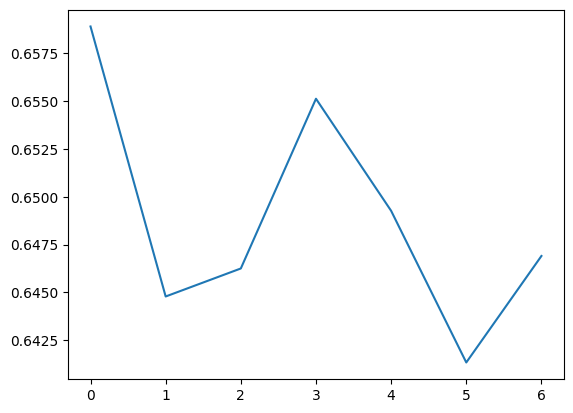

In [31]:
plt.plot(retention_rates)

If i save the user name and time bucket then i could track what users typically change, what relative time bucket (time of the week) is associated with change, and how this differs (or similar) across different time aggregations.

From initial results it look like the larger aggregation levels are more stable (in terms of the retention rate). This is potentially as expected.